# 01. Basic Mosquito Trajectory EDA
Fundamental data quality checks, normalization, and basic kinematic analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
from tqdm.auto import tqdm
from scipy.fft import fft, fftfreq

DATA_DIR = '../data/open/train/'
LABEL_PATH = '../data/open/train_labels.csv'
DT = 0.040

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

c:\Repo\dacon-mosquito-trajectory\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading

In [2]:
train_files = sorted(glob(os.path.join(DATA_DIR, '*.csv')))
def load_trajectories(file_list, limit=1000):
    all_data = []
    for f in tqdm(file_list[:limit]):
        df = pd.read_csv(f)
        df['ID'] = os.path.basename(f).split('.')[0]
        all_data.append(df)
    return pd.concat(all_data, ignore_index=True)

df_sample = load_trajectories(train_files, limit=1000)

100%|██████████| 1000/1000 [00:06<00:00, 149.09it/s]


## 2. Normalization

In [3]:
def normalize_trajectories(df):
    df_norm = df.copy()
    origins = df_norm.groupby('ID').tail(1)[['ID', 'x', 'y', 'z']].set_index('ID')
    for id_val in df_norm['ID'].unique():
        mask = df_norm['ID'] == id_val
        df_norm.loc[mask, ['x', 'y', 'z']] -= origins.loc[id_val].values
    return df_norm

df_normalized = normalize_trajectories(df_sample)

## 3. Kinematics

In [4]:
def add_kinematics(df):
    df = df.copy()
    for col in ['x', 'y', 'z']: df[col] = df[col].astype(float)
    df[['vx', 'vy', 'vz']] = df.groupby('ID')[['x', 'y', 'z']].diff() / DT
    v_vals = df[['vx', 'vy', 'vz']].values.astype(float)
    df['speed'] = np.sum(v_vals**2, axis=1)**0.5
    df[['ax', 'ay', 'az']] = df.groupby('ID')[['vx', 'vy', 'vz']].diff() / DT
    a_vals = df[['ax', 'ay', 'az']].values.astype(float)
    df['acc'] = np.sum(a_vals**2, axis=1)**0.5
    cross = np.cross(v_vals, a_vals)
    cross_mag = np.sum(cross**2, axis=1)**0.5
    df['curvature'] = cross_mag / (df['speed']**3 + 1e-6)
    return df.dropna()

df_kin = add_kinematics(df_normalized)
df_kin[['speed', 'acc', 'curvature']].describe()

,speed,acc,curvature
count,9000.000000,9000.000000,9000.000000
mean,0.623069,3.337582,18.575478
std,0.347255,4.524913,125.218076
min,0.010633,0.011490,0.027494
25%,0.362202,1.099782,2.421481
50%,0.565411,2.037510,5.192675
75%,0.828413,3.677602,11.202907
max,1.349747,57.595456,6225.396592


## 4. FFT & Visualization

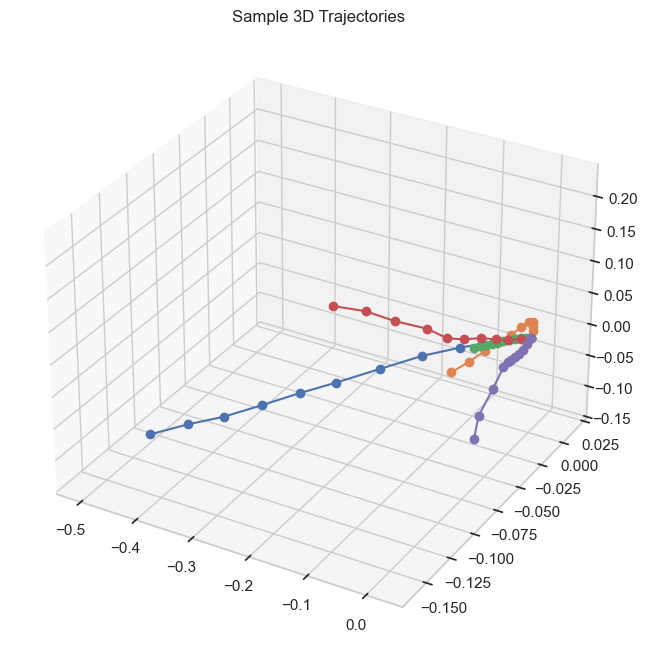

In [5]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
for tid in df_normalized['ID'].unique()[:5]:
    traj = df_normalized[df_normalized['ID'] == tid]
    ax.plot(traj['x'], traj['y'], traj['z'], marker='o', label=tid)
ax.set_title('Sample 3D Trajectories')
plt.show()